# Assignment 1 -- Fourier Analysis (58 points)


---

### Before you start

As many of you have not worked with Fourier Analysis before, this assignment is designed to help you get some experience working with Fourier Transforms (both with pen and paper calculations and in the context of programs)

**Questions 1 and 2 must be solved without a computer** You can use a calculator. You can write code to check your work. Honesty is expected.

**Questions 3 to 7 use Python.** Backbone code is provided; you fill in the marked sections.
For Questions 3 and 4 you are asked to **write down a prediction before you run anything**.
Points will not be deducted for wrong predictions, but you're expected to explain why you predicted wrongly, and what you learnt from the mistake.

Answer in the markdown cells provided. Keep code and prose together — a plot with no
sentence explaining it earns nothing.

You are expected to provide an explanation for each question. Programs unaccompanied by qualitative and/or quantitative interpretations will be penalized.

### Submitting

Submit this notebook with all cells run, plus an HTML or PDF export. 
Describe every figure you produce in one sentence in the text, so the notebook is
followable without seeing the images.

### Notation

$N$ is the length of a discrete signal, $u$ and $v$ index frequency, $n$ and $m$ index position.

$$\mathscr{L}[u] \;=\; \sum_{n=0}^{N-1} \ell[n]\,\exp\!\left(-\frac{2\pi j\,un}{N}\right)$$


## Setup

Run these cells first.

In [ ]:
#Instructions: 1. Run the following on terminal (not notebook!)
#2. Restart the notebook server
#3. Choose "Computer Vision" as the kernel

python3.10 -m venv ~/cvenv
source ~/cvenv/bin/activate
pip install --upgrade pip
pip install "numpy>=2" "scipy>=1.14" "matplotlib>=3.9" jupyter
python -m ipykernel install --user --name cv --display-name "Computer Vision"

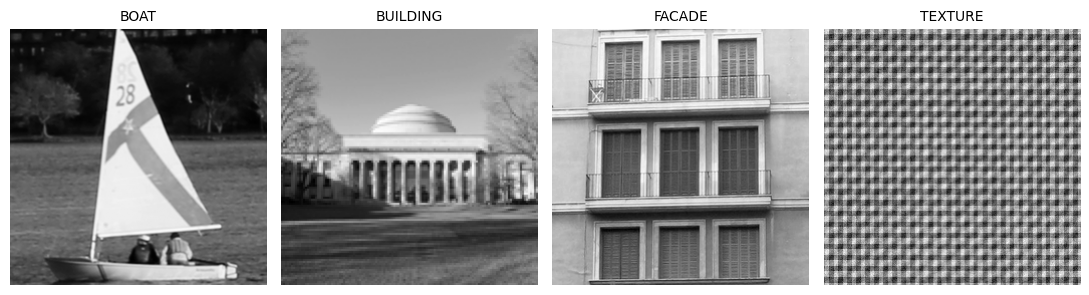

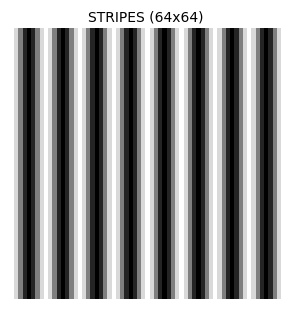

shapes: (256, 256) (256, 256) (256, 256) (256, 256) (64, 64)


In [1]:
# Run this cell first to the images and define a few helpers.
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fft2, ifft2, fftshift, ifftshift

plt.rcParams["figure.figsize"] = (11, 3.2)
plt.rcParams["image.cmap"] = "gray"

def load(name):
    """Load one of the provided images as a float array in [0, 1]."""
    return plt.imread(f"images/{name}.png").astype(float)[..., 0] \
           if plt.imread(f"images/{name}.png").ndim == 3 \
           else plt.imread(f"images/{name}.png").astype(float)

def show(*pairs):
    """show(img, "title", img2, "title2", ...) - display images side by side."""
    imgs = pairs[0::2]; titles = pairs[1::2]
    fig, axes = plt.subplots(1, len(imgs))
    if len(imgs) == 1: axes = [axes]
    for ax, im, t in zip(axes, imgs, titles):
        ax.imshow(im); ax.set_title(t, fontsize=10); ax.axis("off")
    plt.tight_layout(); plt.show()

def spectrum(img):
    """Log amplitude spectrum, origin at the centre. Use this for every
    spectrum you plot - a raw spectrum shows one bright dot and nothing else."""
    return np.log1p(np.abs(fftshift(fft2(img))))

BOAT     = load("boat")       # 256x256, a natural scene with strong contours
BUILDING = load("building")   # 256x256, strong oriented edges
FACADE   = load("facade")     # 256x256, a building facade - note the windows
TEXTURE  = load("texture")    # 256x256, a woven cloth - strongly periodic
STRIPES  = load("stripes")    #   64x64, vertical stripes, period exactly 8 px

show(BOAT, "BOAT", BUILDING, "BUILDING", FACADE, "FACADE", TEXTURE, "TEXTURE")
show(STRIPES, "STRIPES (64x64)")
print("shapes:", BOAT.shape, BUILDING.shape, FACADE.shape, TEXTURE.shape, STRIPES.shape)

---

## Question 1 — 10 points

**Do this question without a computer.** Write your working in the answer cell.
The discrete Fourier transform of a length-$N$ signal is

$$\mathscr{L}[u] \;=\; \sum_{n=0}^{N-1} \ell[n]\,\exp\!\left(-\frac{2\pi j\,un}{N}\right)$$

**(a) [3]** Write down the four values of $\exp(-2\pi j\,k/4)$ for $k=0,1,2,3$. Each is one of $1$, $-1$, $j$, $-j$ — say which.

**(b) [3]** Compute the DFT of $\ell = [1,1,1,1]$ directly from the definition. Exactly one coefficient is non-zero.

**(c) [3]** Compute the DFT of $\ell = [1,-1,1,-1]$. Again exactly one is non-zero. Which, and why that one rather than the one from (b)?

**(d) [1]** Without computing anything, state $\mathscr{L}[0]$ for $\ell = [3,1,0,1]$, and say in one sentence why that coefficient is free.

In [ ]:
# Optional: check your hand-computed answers here after you have done them.
# np.round(fft([1, 1, 1, 1]), 6

### Your answer

**(a)** From Section 16.4.2 Complex Exponentials, I calculated the four values for $k=0,1,2,3$ using $\exp(-2\pi j\,k/4)=\exp(-\pi j\,k/2)$ and Euler Equation 16.1, $\exp(j\,a)=\cos(a) + j\ \sin(a)$.

**$k=0$, $\exp(-\pi j\ \frac{0}{2})$**

$\exp(j (0))=\cos(0)+j\,\sin(0)=1+j\cdot0=1$

**$k=1$, $\exp(-\pi j\ \frac{1}{2})$**

$\exp(j (-\frac{\pi}{2}))=\cos(-\frac{\pi}{2})+j\,\sin(-\frac{\pi}{2})=0+j\cdot-1=-j$

**$k=2$, $\exp(-\pi j\ \frac{2}{2})$**

$\exp(j (-\pi))=\cos(-\pi)+j\,\sin(-\pi)=-1+j\cdot0=-1$

**$k=3$, $\exp(-\pi j\ \frac{3}{2})$**

$\exp(j \frac{3}{2}\pi)=\cos(\frac{-3}{2}\pi)+j\,\sin(\frac{-3}{2}\pi)=0+j\cdot1=j$

**(b)** I used the Discrete Fourier Equation $\mathscr{L}[u] \;=\; \sum_{n=0}^{N-1} \ell[n]\,\exp\!\left(-\frac{2\pi j\,un}{N}\right)$ to compute the DFT of $\ell = [1,1,1,1]$.

**$u=0$, $\ell[0]\,\exp\!\left(-\frac{2\pi j\,0\cdot0}{4}\right)+\ell[1]\,\exp\!\left(-\frac{2\pi j\,0\cdot1}{4}\right)+\ell[2]\,\exp\!\left(-\frac{2\pi j\,0\cdot2}{4}\right)+\ell[3]\,\exp\!\left(-\frac{2\pi j\,0\cdot3}{4}\right)$**

$\ell[0]\,\exp\!\left(0\right)+\ell[1]\,\exp\!\left(0\right)+\ell[2]\,\exp\!\left(0\right)+\ell[3]\,\exp\!\left(0\right)=1\cdot1+1\cdot1+1\cdot1+1\cdot1=4$

**$u=1$, $\ell[0]\,\exp\!\left(-\frac{2\pi j\,1\cdot0}{4}\right)+\ell[1]\,\exp\!\left(-\frac{2\pi j\,1\cdot1}{4}\right)+\ell[2]\,\exp\!\left(-\frac{2\pi j\,1\cdot2}{4}\right)+\ell[3]\,\exp\!\left(-\frac{2\pi j\,1\cdot3}{4}\right)$**

$\ell[0]\,\exp\!\left(0\right)+\ell[1]\,\exp\!\left(-\frac{\pi}{2}j\right)+\ell[2]\,\exp\!\left(-\pi j\right)+\ell[3]\,\exp\!\left(-\frac{3\pi}{2}j\right)=1\cdot1+1\cdot -j+1\cdot-1+1\cdot j=0$

**$u=2$, $\ell[0]\,\exp\!\left(-\frac{2\pi j\,2\cdot0}{4}\right)+\ell[1]\,\exp\!\left(-\frac{2\pi j\,2\cdot1}{4}\right)+\ell[2]\,\exp\!\left(-\frac{2\pi j\,2\cdot2}{4}\right)+\ell[3]\,\exp\!\left(-\frac{2\pi j\,2\cdot3}{4}\right)$**

$\ell[0]\,\exp\!\left(0\right)+\ell[1]\,\exp\!\left(-\pi j\right)+\ell[2]\,\exp\!\left(-2\pi j\right)+\ell[3]\,\exp\!\left(-3\pi j\right)=1\cdot1+1\cdot-1+1\cdot1+1\cdot-1=0$

**$u=3$, $\ell[0]\,\exp\!\left(-\frac{2\pi j\,3\cdot0}{4}\right)+\ell[1]\,\exp\!\left(-\frac{2\pi j\,3\cdot1}{4}\right)+\ell[2]\,\exp\!\left(-\frac{2\pi j\,3\cdot2}{4}\right)+\ell[3]\,\exp\!\left(-\frac{2\pi j\,3\cdot3}{4}\right)$**

$\ell[0]\,\exp\!\left(0\right)+\ell[1]\,\exp\!\left(-\frac{3\pi}{2}j\right)+\ell[2]\,\exp\!\left(-3\pi j\right)+\ell[3]\,\exp\!\left(-\frac{9\pi}{2}\right)=1\cdot1+1\cdot j+1\cdot-1+1\cdot -j=0$

**(c)** This time I computed the DFT of $\ell = [1,-1,1,-1]$

In [ ]:
# Your code, if you need more room.


---

## Question 2 — Reading a transfer function  *(8 points)*

The three-tap blur kernel $[1,2,1]$ has transfer function

$$B[u] \;=\; 2 + 2\cos\!\left(\frac{2\pi u}{N}\right)$$

Note: this is another way of saying that $B[u]$ is the DFT of the kernel $[1, 2, 1]$

**(a) [2]** Evaluate $B[u]$ at $u=0$ and at $u=N/2$.

**(b) [3]** Say in plain words what each of those numbers means for what the filter does to an image. What input signal corresponds to $u=N/2$?

**(c) [3]** The box kernel $[1,1,1]$ has transfer function $\dfrac{\sin(3\pi u/N)}{\sin(\pi u/N)}$. Evaluate it at $u=N/2$ and compare with (a). Which is the better blur filter, and why?

### Your answer

*(replace this text)*

---

## Question 3 — Predicting a spectrum  *(8 points)*

`STRIPES` is a $64\times64$ image of vertical stripes whose pattern repeats exactly every $8$ pixels.

**(a) [0]** **Before running anything**, predict the coordinates $(u,v)$ of the bright peaks in its amplitude spectrum. Give actual numbers, not a description. Write the prediction in the answer cell now.

**(b) [2]** Explain why the peaks appear in pairs.

**(c) [6]** Verify numerically. If your prediction was wrong, say what you had misunderstood — do not simply correct the numbers.

In [ ]:
show(STRIPES, "STRIPES (64x64, period 8 px)")

# YOUR CODE for part (c): compute the spectrum and find the peak locations.
# Hint: np.argwhere(A > 0.5*A.max()) on the shifted amplitude, then subtract
# the centre index to get coordinates relative to the origin.


### Your answer

*(replace this text)*

In [ ]:
# Your code, if you need more room.


---

## Question 4 — Amplitude against phase  *(12 points)*

Take `BOAT` and `BUILDING`. Compute both transforms, then build two hybrids: the **amplitude of one** combined with the **phase of the other**, and vice versa.

**(a) [0]** **Before running anything**, predict which parent each hybrid will resemble. Write the prediction down.

**(b) [6]** Produce the two hybrids and describe what you see.

**(c) [6]** The conclusion *"all the information is in the phase"* is too strong. Repeat the experiment on `TEXTURE` and on `FACADE`, this time comparing

- the **true amplitude** with a randomised phase, against
- a generic $1/f$ amplitude with the **true phase**.

For which image does amplitude win? Explain what property of that image is responsible, and say where `FACADE` sits between the two extremes.

*Hint: what kind of image has a spectrum made of a few isolated points rather than a broad smear?*

In [ ]:
def to_polar(img):
    """Return (amplitude, phase) of the 2D DFT of img."""
    L = fft2(img)
    return np.abs(L), np.angle(L)

def from_polar(amp, phase):
    """Rebuild a real image from an amplitude and a phase."""
    return np.real(ifft2(amp * np.exp(1j * phase)))

# YOUR CODE (b): build the two hybrids and show them.

# YOUR CODE (c): run the comparison on TEXTURE, FACADE and BOAT.
# The helper below gives you the generic amplitude.

def generic_amplitude(shape, b=1.0):
    """A 1/(u^2+v^2)^b amplitude spectrum - the average natural image."""
    M, N = shape
    u = fftshift(np.arange(M) - M//2); v = fftshift(np.arange(N) - N//2)
    U, V = np.meshgrid(u, v, indexing="ij")
    r2 = U**2 + V**2; r2[0, 0] = 1.0
    A = 1.0 / r2**b
    A[0, 0] = A.max() * 10
    return A


### Your answer

*(replace this text)*

In [ ]:
# Your code, if you need more room.


---

## Question 5 — Two shifts  *(10 points)*

**(a) [6]** Shift `BUILDING` by $7$ pixels horizontally. Show numerically that the **amplitude spectrum is unchanged**. Then show that the phase changed, and describe the pattern: how does the phase difference vary with the frequency index?

**(b) [4]** Multiply `BUILDING` pointwise by $(-1)^{n+m}$ and then transform it. Describe what happened to the spectrum, and explain it using the modulation property.
PS: You may want to use fftshift.



In [ ]:
shifted = np.roll(BUILDING, 7, axis=1)
show(BUILDING, "BUILDING", shifted, "shifted 7 px right")

# YOUR CODE (a): compare the two amplitude spectra, then look at the phase
# difference as a function of frequency index. np.angle and np.unwrap help.

# YOUR CODE (b): build the (-1)^(n+m) checkerboard and multiply.
# n, m = np.meshgrid(np.arange(256), np.arange(256), indexing="ij")


### Your answer

*(replace this text)*

In [ ]:
# Your code, if you need more room.


---

## Question 6 — Convolution two ways  *(10 points)*

**(a) [4]** Convolve `BOAT` with a $15\times15$ Gaussian kernel directly. Then do the same via the FFT: transform both, multiply pointwise, transform back. Confirm the two agree.

**(b) [3]** Time both methods for kernel sizes $3, 7, 15, 31, 63$. Report the crossover size at which the FFT route becomes faster.

**(c) [3]** The two results agree *almost* everywhere. Where do they differ, and why? Your answer should mention boundary conditions.

In [ ]:
import time
from scipy.signal import convolve2d

def gaussian_kernel(size, sigma=None):
    """A normalised square Gaussian kernel."""
    if sigma is None: sigma = size/6.0
    a = np.arange(size) - (size-1)/2
    g = np.exp(-a**2/(2*sigma**2))
    k = np.outer(g, g)
    return k / k.sum()

def fft_convolve(img, kernel):
    """Circular convolution via the FFT, kernel centred."""
    K = np.zeros_like(img)
    s = kernel.shape[0]; c = s//2
    K[:s, :s] = kernel
    K = np.roll(K, (-c, -c), axis=(0, 1))     # put the kernel centre at [0,0]
    return np.real(ifft2(fft2(img) * fft2(K)))

# YOUR CODE (a): compare convolve2d(..., mode="same") with fft_convolve.
# YOUR CODE (b): time both for several kernel sizes.
# YOUR CODE (c): look at where they differ - try imshow of the absolute difference.


### Your answer

*(replace this text)*

In [ ]:
# Your code, if you need more room.


---

*Images adapted from* Foundations of Computer Vision *by Torralba, Isola and Freeman
(visionbook.mit.edu), CC BY-NC-ND, for non-commercial classroom use.*